In [1]:
import os
import re
import sys
from collections import Counter, defaultdict

import krippendorff
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import wilcoxon

In [2]:
# Get the current working directory (which is notebooks/)
notebook_dir = os.getcwd()
# Get the parent directory (the project root)
project_root = os.path.dirname(notebook_dir)

# Add the project root to the Python path
if project_root not in sys.path:
    sys.path.append(project_root)
# ------------------------------------

# Now this import will work correctly
from src.evaluation.calculate_metrics import (
    Squared_diff_list,
    bootstrap_alpha,
    bootstrap_mse_models,
    hist_dist,
    plot_bootstrapped_msd,
    plot_CI,
    plot_mean_diff_models_vs_human,
)

In [3]:
# Fetching Data
df_mikkel = pd.read_json("../src/annotation/annotations_mikkel.json")
df_david = pd.read_json("../src/annotation/annotations_david.json")
df_carl = pd.read_json("../src/annotation/annotations_carl.json")
df_models = pd.read_csv("../results/test_results_with_predictions.csv")


# Fix of dataframe
def parse_label_string(label_str):
    return re.findall(r"'(.*?)'", label_str)


df_mikkel["original_label"] = df_mikkel["original_label"].apply(parse_label_string)

# Check:
df_mikkel["original_label"].iloc[0][0]

'None'

In [4]:
# Fetching model results
df_models = pd.read_csv("../results/test_results_with_predictions.csv")

model_data = defaultdict(list)

raw_cols = [col for col in df_models.columns if col.startswith("raw")]
for col in raw_cols:
    model_data[col] = df_models[col].tolist()

In [5]:
# Preparing data and setting variables

num_encoder = {
    "None": 0,
    "Minimal": 1,
    "Basic": 2,
    "Good": 3,
    "Excellent": 4,
    "❗ Problematic Content ❗": 0,  # for security
}

N = len(df_mikkel)
R = 5  # number of ratings

score_dict = {}
score_data = []

for i in range(len(df_mikkel)):
    labels = [
        df_carl["our_label"].iloc[i],
        df_mikkel["our_label"].iloc[i],
        df_david["our_label"].iloc[i],
    ] + df_mikkel["original_label"].iloc[i]
    scores = [num_encoder[label] for label in labels]
    id_ = df_mikkel["id"].iloc[i]
    score_dict[id_] = scores  # dict of lists
    score_data.append(scores)  # list of lists

/var/folders/js/tk26df7j5qz2m906xlhckh5r0000gn/T/ipykernel_18685/1155500219.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


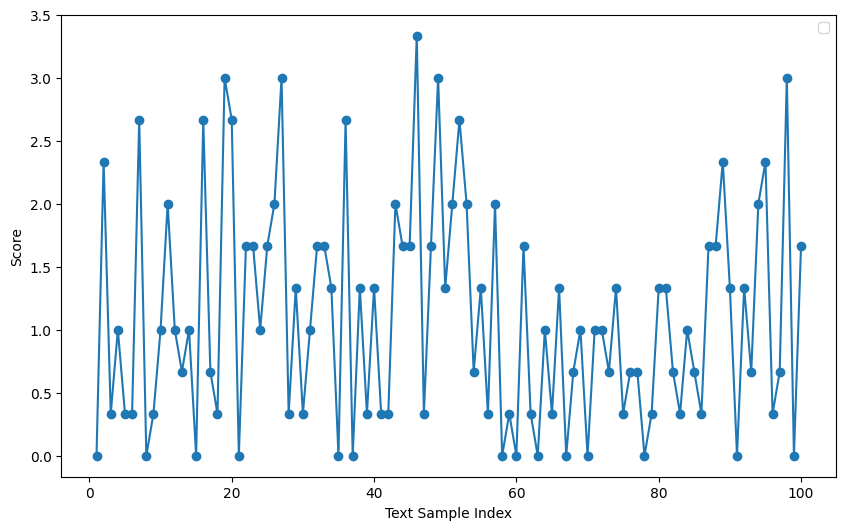

In [6]:
# Plotting the average score to look for trends
our_score_data = [scores[:3] for scores in score_data]  # Only our labels (Mikkel, David, Carl)

plt.figure(figsize=(10, 6))
plt.plot(range(1, N + 1), [np.mean(scores) for scores in our_score_data], marker="o")
plt.xlabel("Text Sample Index")
plt.ylabel("Score")
plt.legend()
plt.show()

____

## Global aggreement: MSD and Krippendorffs $\alpha$

### MSD

In [7]:
def Mean_Squared_Diff(score_data):  # <-- list of lists
    SD_list = []

    for scores in score_data:
        c = len(scores)
        # The Squared Difference between unordered distinct pairs for one text:
        SD = (2 / (c * (c - 1))) * sum((scores[j] - scores[k]) ** 2 for j in range(c) for k in range(j + 1, c))
        SD_list.append(SD)

    return np.mean(SD_list)


MSD = np.mean(Mean_Squared_Diff(score_data))

MSD

np.float64(1.2646666666666666)

### Krippendorff's $\alpha$

In [8]:
# Alpha calculated with library
def K_alpha(score_data, datatype):
    reliability_data = np.array(score_data).T
    alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement=datatype)
    return alpha


alpha = K_alpha(score_data, "interval")
alpha

np.float64(0.4401220957303449)

In [9]:
# Alpha calculated by hand assuming equal intervals:

D_o = MSD

# All annotation scores
all_scores = np.asarray(score_data).flatten()


label_counts = Counter(all_scores)  # dict
labels = list(range(R))
n_total = len(all_scores)  # total annotations

# Calculate D_e
De_numerator = 0
for i in range(R):
    for j in range(i + 1, R):
        a = labels[i]
        b = labels[j]
        n_a = label_counts[a]
        n_b = label_counts[b]
        delta = (a - b) ** 2
        De_numerator += n_a * n_b * delta

D_e = De_numerator * 2 / (n_total * (n_total - 1))

alpha_simplifed = 1 - D_o / D_e
alpha_simplifed

np.float64(0.4401220957303449)

In [10]:
# Comparing to ordinal delta function
alpha_ordinal = K_alpha(score_data, "ordinal")
diff_alpha = alpha - alpha_ordinal

print(f"alpha (interval): {alpha}")
print(f"alpha (ordinal): {alpha_ordinal}")
print(f"Difference (alpha - alpha_ordinal): {diff_alpha}")

alpha (interval): 0.4401220957303449
alpha (ordinal): 0.44388382293447715
Difference (alpha - alpha_ordinal): -0.003761727204132259


_______
## Comparing annotator-groups

In [11]:
n = 3  # number of author annotators

human_data = {
    "author": [scores[:n] for scores in score_data],
    "fineweb": [scores[n:] for scores in score_data],
    "all": score_data,
}

agreement = {}
for name2, list_score in human_data.items():
    agreement[name2] = (
        Mean_Squared_Diff(list_score),
        K_alpha(list_score, "ordinal"),
        np.mean([np.mean(scores) for scores in list_score]),
    )
agreement

{'author': (np.float64(0.9666666666666666),
  np.float64(0.560818764498379),
  np.float64(1.106666666666667)),
 'fineweb': (np.float64(1.6066666666666665),
  np.float64(0.3381319866159098),
  np.float64(0.9500000000000002)),
 'all': (np.float64(1.2646666666666666),
  np.float64(0.44388382293447715),
  np.float64(1.0283333333333333))}

### Statistic tests

In [12]:
# Normality for MSD
from scipy.stats import shapiro

# Function to calculate a list of mean squared differences for each sample was imported from results_functions.py

# Shapiro Wilk
stat, p_aut = shapiro(Squared_diff_list(human_data["author"]))
print(f"Shapiro-Wilk p 'author' = {p_aut}")

stat, p_fine = shapiro(Squared_diff_list(human_data["fineweb"]))
print(f"Shapiro-Wilk p 'fineweb' = {p_fine}")

np.mean(Squared_diff_list(score_data))

Shapiro-Wilk p 'author' = 5.730903158670627e-13
Shapiro-Wilk p 'fineweb' = 2.761921713048834e-10


np.float64(1.2646666666666666)

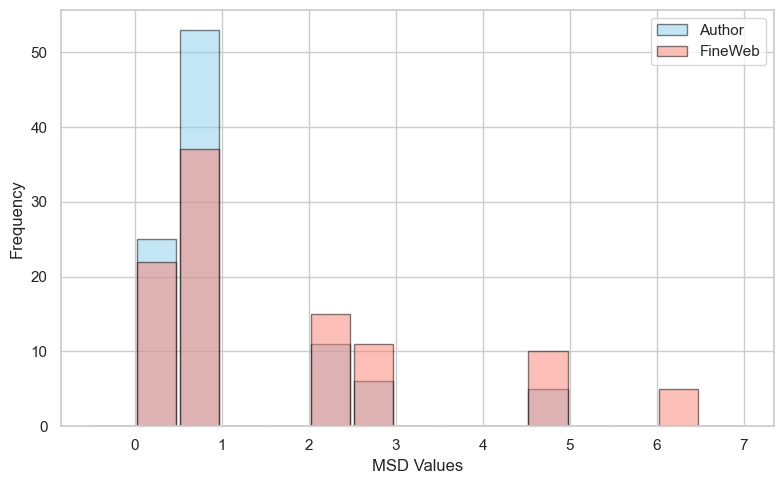

In [13]:
# imported from functions_results.py
hist_dist(human_data["author"], human_data["fineweb"], "Author", "FineWeb", "msd")

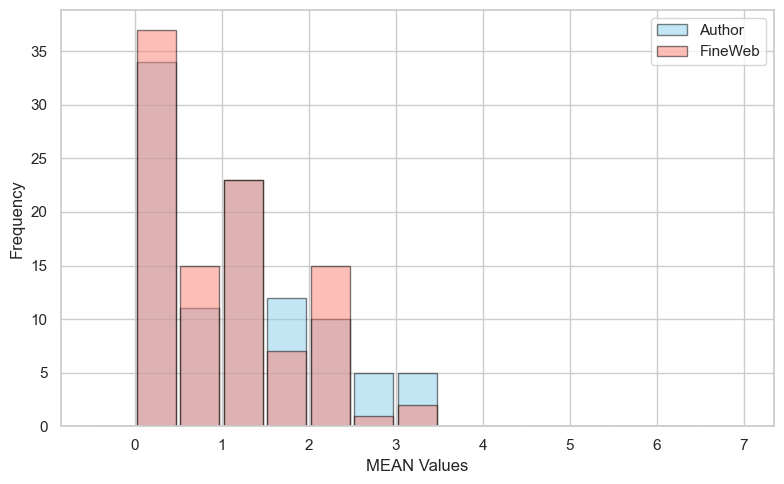

In [14]:
hist_dist(human_data["author"], human_data["fineweb"], "Author", "FineWeb", "mean")

In [15]:
def wilcoxon_test(sample1, sample2, type):
    if type == "msd":
        list1 = Squared_diff_list(sample1)
        list2 = Squared_diff_list(sample2)

    elif type == "mean":
        if isinstance(sample1[0], float):
            list1 = sample1
        else:
            list1 = [np.mean(scores) for scores in sample1]
        if isinstance(sample2[0], float):
            list2 = sample2
        else:
            list2 = [np.mean(scores) for scores in sample2]
    else:
        return "Error"

    return wilcoxon(list1, list2)  # returns --> wilcoxon_stat, wilcoxon_p$

In [16]:
# Paired test
wilcoxon_stat_msd, wilcoxon_p_msd = wilcoxon_test(human_data["author"], human_data["fineweb"], "msd")
wilcoxon_stat_mean, wilcoxon_p_mean = wilcoxon_test(human_data["author"], human_data["fineweb"], "mean")

print(f"Wilcoxon p-value (MSD): {wilcoxon_p_msd}")
print(f"Wilcoxon p-value (Mean): {wilcoxon_p_mean}")

Wilcoxon p-value (MSD): 0.0019335420818070834
Wilcoxon p-value (Mean): 0.024049874094710655


___
## Comparing our trained models

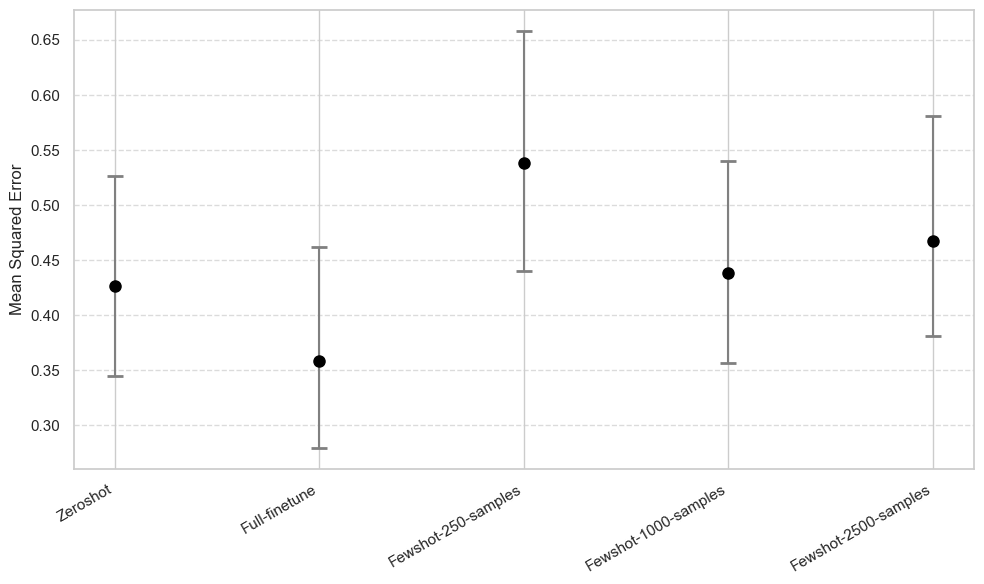

In [17]:
# Bootstrap confidence intervals for model MSEs
y_human = np.array([np.mean(scores) for scores in score_data])

# impoorted from results_functions.py
bootstrap_mse_models(model_data, y_human, 10000)

All models predicted significantly different scores than the human mean. (p-value > 0.05).

___
### Comparing Models to Human scores

In [18]:
data_model_human = model_data.copy()
data_model_human["Human"] = score_data

MEAN

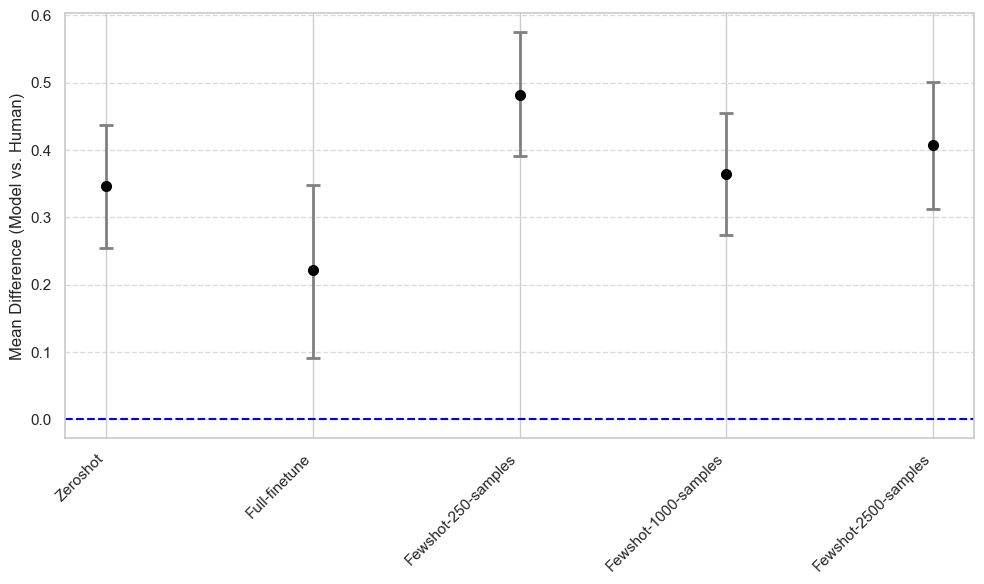

In [19]:
# Plotting the bootstrapped CIs of the differences between model predictions and mean human annotations:
plot_mean_diff_models_vs_human(data_model_human)

DISAGREEMENT

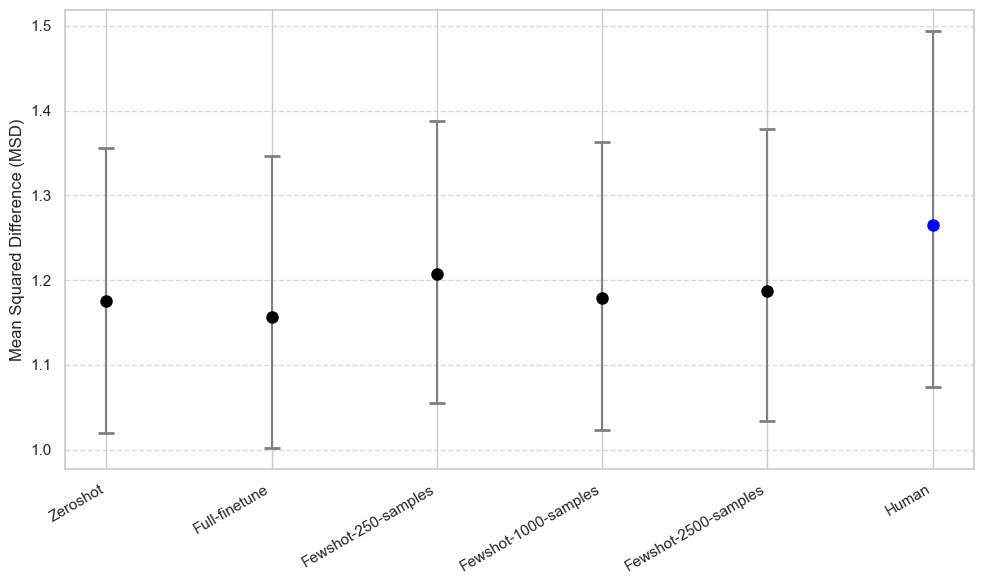

In [20]:
# Plotting the bootstrapped CI of mean MSDs of human annotations + each models predictions separately:
plot_bootstrapped_msd(data_model_human)

In [21]:
# Statistical test

# first
# Checking for normality of human scores
shapiro_stat, shapiro_p = shapiro([np.mean(scores) for scores in score_data])
float(shapiro_p)

9.851985222540218e-05

No significance (p_shapiro < 0.05)  --> non-parametric tests

In [22]:
# MSD comparison with human scores

for name, scores in model_data.items():
    data_model_and_all = [[scores[i]] + human_data["all"][i] for i in range(len(scores))]

    MSD_diff = Mean_Squared_Diff(data_model_and_all) - Mean_Squared_Diff(score_data)
    alpha_diff = K_alpha(data_model_and_all, "interval") - K_alpha(score_data, "interval")
    print(f"Model {name}, Change in MSD: {MSD_diff}, Change in Alpha: {alpha_diff}")

Model raw_prediction_zeroshot, Change in MSD: -0.08898309579984187, Change in Alpha: -0.020272743866863285
Model raw_prediction_Full-finetune, Change in MSD: -0.10852791985997401, Change in Alpha: 0.0015057512969696152
Model raw_prediction_fewshot-250-samples, Change in MSD: -0.05705650023095954, Change in Alpha: -0.027770695574321103
Model raw_prediction_fewshot-1000-samples, Change in MSD: -0.08567200634609717, Change in Alpha: -0.020698523139291547
Model raw_prediction_fewshot-2500-samples, Change in MSD: -0.07713879233629473, Change in Alpha: -0.021317264959866966


In [23]:
data_model_and_all

[[1.1869676, 0, 0, 0, 0, 0, 0],
 [1.9603031, 3, 1, 3, 2, 2, 1],
 [1.1297121, 0, 1, 0, 0, 0, 2],
 [1.4692192, 2, 1, 0, 2, 0, 0],
 [1.60134, 1, 0, 0, 0, 0, 0],
 [1.1336297, 0, 1, 0, 0, 1, 0],
 [2.0418239, 3, 2, 3, 2, 4, 2],
 [0.48560035, 0, 0, 0, 1, 0, 1],
 [1.2232921, 0, 1, 0, 0, 3, 0],
 [1.4822812, 0, 2, 1, 2, 1, 3],
 [1.8877207, 2, 2, 2, 0, 1, 3],
 [1.7482166, 1, 1, 1, 1, 1, 1],
 [1.7914827, 0, 1, 1, 1, 1, 0],
 [1.5344856, 1, 1, 1, 1, 1, 1],
 [0.44011045, 0, 0, 0, 0, 0, 1],
 [1.5836641, 4, 3, 1, 3, 1, 2],
 [2.0008914, 0, 2, 0, 2, 0, 0],
 [1.3414106, 0, 1, 0, 1, 0, 1],
 [2.682198, 3, 4, 2, 2, 1, 4],
 [2.1460874, 3, 3, 2, 0, 0, 2],
 [0.96763515, 0, 0, 0, 0, 0, 0],
 [1.2509508, 1, 2, 2, 1, 2, 1],
 [1.5353775, 2, 2, 1, 0, 1, 3],
 [1.08523, 1, 2, 0, 0, 0, 0],
 [1.4797817, 2, 2, 1, 2, 1, 2],
 [1.6758358, 2, 3, 1, 1, 0, 3],
 [2.4397817, 4, 3, 2, 0, 0, 1],
 [1.1629622, 0, 1, 0, 1, 0, 2],
 [1.2287464, 1, 2, 1, 1, 1, 4],
 [0.93468744, 0, 1, 0, 0, 0, 0],
 [1.4062474, 1, 2, 0, 3, 2, 1],
 [1.60108

No models significantly raise the inter-annotator disagreement (MSD) when added the human annotators (p-values > 0.05). The MSD before the models where added was 1.26. However, more test data might reduce the margins ofthe CIs and show otherwise.

In [ ]:
CI_data = []
model_names = []
for name2, predictions in data_model_human.items():
    model_names.append(name2[15:].capitalize() if name2 != "Human" else "Human")

    if name2 != "Human":
        # Add model predictions to human ratings per sample
        combined = [np.append(score_data[i], predictions[i]) for i in range(len(predictions))]
    else:
        combined = score_data

    # from results_functions.py
    CI_data.append(bootstrap_alpha(combined))

  0%|          | 0/1000 [00:00<?, ?it/s]

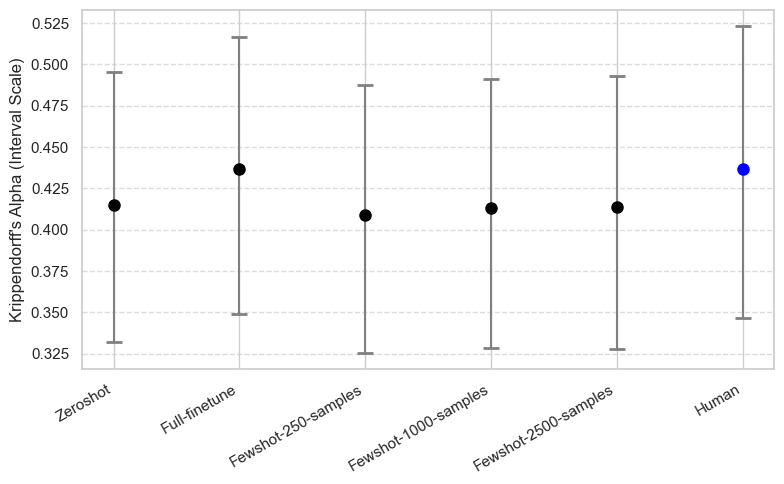

In [ ]:
plot_CI(CI_data, model_names, title=None, ylabel="Krippendorff's Alpha (Interval Scale)")

___
## Comparing classes
We create pools for each annotation class, including all items where a specific class was annotated at least once.

In [ ]:
agreement_pools = {}
pools = {}
for i in range(R):
    pool = [scores for scores in human_data["all"] if i in scores]
    agreement_pools[i] = (
        Mean_Squared_Diff(pool),
        K_alpha(pool, "interval"),
        K_alpha(pool, "nominal"),
    )
    pools[f"Score {i}"] = pool
    print(pool)
    count = 0
    for s in pool:
        if s.count(i) >= 2:
            count += 1
    print(f"Number of samples in pool with at least two '{i}'s: {count} / {len(pool)}")

agreement_pools

[[0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 2], [2, 1, 0, 2, 0, 0], [1, 0, 0, 0, 0, 0], [0, 1, 0, 0, 1, 0], [0, 0, 0, 1, 0, 1], [0, 1, 0, 0, 3, 0], [0, 2, 1, 2, 1, 3], [2, 2, 2, 0, 1, 3], [0, 1, 1, 1, 1, 0], [0, 0, 0, 0, 0, 1], [0, 2, 0, 2, 0, 0], [0, 1, 0, 1, 0, 1], [3, 3, 2, 0, 0, 2], [0, 0, 0, 0, 0, 0], [2, 2, 1, 0, 1, 3], [1, 2, 0, 0, 0, 0], [2, 3, 1, 1, 0, 3], [4, 3, 2, 0, 0, 1], [0, 1, 0, 1, 0, 2], [0, 1, 0, 0, 0, 0], [1, 2, 0, 3, 2, 1], [0, 2, 3, 1, 1, 1], [0, 0, 0, 0, 0, 1], [3, 4, 1, 3, 2, 0], [0, 0, 0, 0, 0, 0], [0, 3, 1, 0, 1, 2], [0, 1, 0, 0, 1, 0], [2, 2, 0, 0, 1, 3], [0, 1, 0, 0, 0, 0], [0, 1, 0, 0, 0, 1], [0, 1, 0, 1, 0, 0], [1, 2, 2, 0, 3, 1], [1, 2, 1, 1, 3, 0], [0, 1, 1, 0, 0, 0], [0, 1, 0, 1, 1, 1], [0, 0, 0, 0, 0, 0], [0, 1, 0, 1, 1, 0], [0, 0, 0, 0, 1, 0], [1, 1, 3, 1, 0, 0], [0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 1, 2, 1, 0, 2], [0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0], [1, 0, 1, 0, 1, 0], [1, 1, 1, 0, 0, 0], [0, 0, 0, 0, 0, 1], [1, 1, 1, 1, 0, 1], [1, 1, 1, 0, 0, 1],

{0: (np.float64(1.1981981981981982),
  np.float64(0.22475),
  np.float64(0.07934703347696381)),
 1: (np.float64(1.3450980392156862),
  np.float64(0.3109921898740673),
  np.float64(0.08497435840388046)),
 2: (np.float64(1.851190476190476),
  np.float64(0.219932763797273),
  np.float64(0.009585953256614044)),
 3: (np.float64(2.25),
  np.float64(0.11471659747521812),
  np.float64(-0.03136084679916662)),
 4: (np.float64(2.5380952380952375),
  np.float64(-0.017105414415450104),
  np.float64(-0.025458629726694104))}

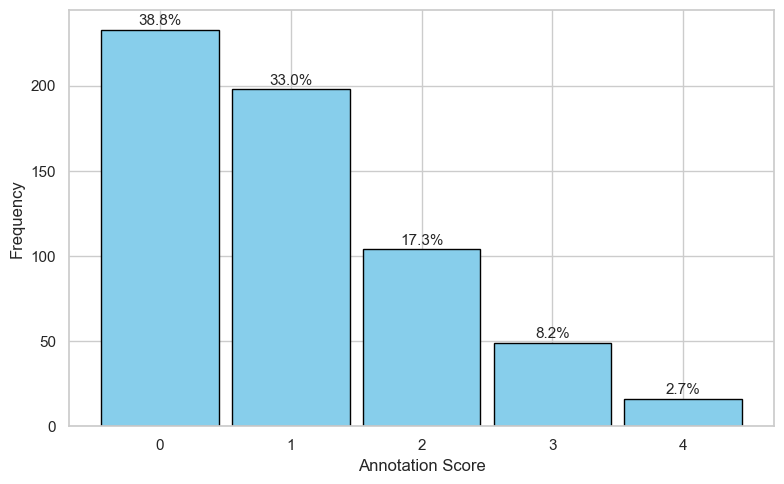

In [ ]:
sns.set(style="whitegrid")

bins = [x - 0.5 for x in range(6)]

plt.figure(figsize=(8, 5))
counts, _, patches = plt.hist(all_scores, bins=bins, edgecolor="black", color="skyblue", rwidth=0.9)

# Add percentages above bars
total = sum(counts)
for count, patch in zip(counts, patches):
    if count > 0:
        height = patch.get_height()
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            height + 1,
            f"{100 * count / total:.1f}%",
            ha="center",
            va="bottom",
            fontsize=11,
        )

plt.xticks(range(5))
plt.xlabel("Annotation Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
# Displaying IDs with all scores from 0 to 4 (high disagreement)
ids_with_all_scores = [id_ for id_, scores in score_dict.items() if set([0, 1, 2, 3, 4]).issubset(set(scores))]
for id_ in ids_with_all_scores:
    print(f"ID: {id_}, Text: {df_mikkel['text'][df_mikkel['id'] == id_].values[0][:1000]}...")
    print(f"Scores: {score_dict[id_]}")
    print("-" * 40)

ID: 9c41aa98-225a-436f-8fb9-cc2b6588085f, Text: Guzmania - Guzmania
Flerårige urteagtige stemløse planter, epifytter. Radikale blade, der danner en roset, lineær og xiphoid, hele. Peduncle dækket med små blade (forlader midten af roset af blade). Inflorescens spiciform eller panicle, nogle gange i form af et hoved. Blomsterne er placeret i axils af de røde bracts; corolla spongat, med segmenter kortere end røret; keglerne krydser i bunden.
Generelle oplysninger om anlægget Guzmania - Guzmania
Guzmania - Guzmania bromeliad familie.
Antal: I en slægt omkring 110 arter.
Oprindelsessted: Central- og Sydamerika.
Anvendelse: blomstring.
Plante størrelse: op til 30 cm i højden.
Vækst: langsom.
Blomstrende: om sommeren, efterår-vinter.
Guzmania arter - Guzmania
Guzmania lingulata var. Lingulata
Epifyter. Planter 40-45 cm høje. Bladene er bælteformede, 45 cm lange og op til 6 cm brede, bredere ved bunden, grøn over, bunden med rødbrune linjer, bar. Blomstring er et tæt hoved. Kronblade hvidlig;

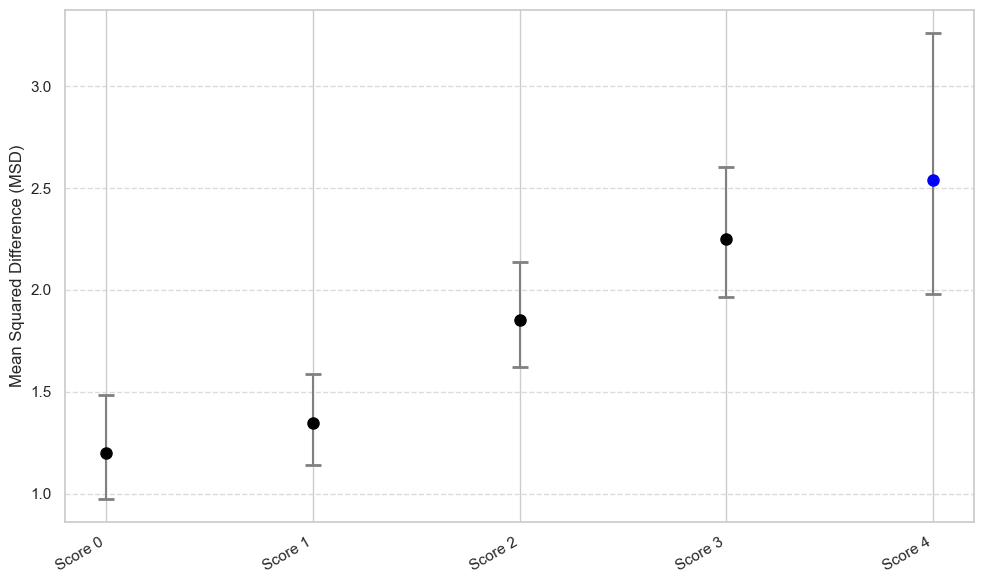

In [ ]:
plot_bootstrapped_msd(pools)

In [ ]:
def Mean_Ordinal_Diff(scores):  # <— one item
    freqs = Counter(scores)
    categories = sorted(freqs.keys())
    total_pairs = 0
    total_OD = 0

    # Iterate over all unordered distinct pairs (a, b) where a < b
    for i in range(len(categories)):
        for j in range(i + 1, len(categories)):
            a, b = categories[i], categories[j]

            # Frequencies of a, b
            n_a = freqs[a]
            n_b = freqs[b]

            # Sum of frequencies between a and b (inclusive)
            n_sum = sum(freqs[g] for g in range(a, b + 1))

            # Ordinal difference formula
            delta_sq = (n_sum - (n_a + n_b) / 2) ** 2

            # Count how many such pairs exist
            pair_count = n_a * n_b
            total_OD += delta_sq * pair_count
            total_pairs += pair_count

    # Normalize by total number of unordered pairs
    if total_pairs > 0:
        return total_OD / total_pairs
    else:
        return 0